# Notebook 04 — RFM Analysis & K-Means Clustering

**Proyek:** Segmentasi Pelanggan untuk Mengatasi Ketidakefektifan Strategi Pemasaran Menggunakan Metode RFM dan Algoritma K-Means

## Tujuan
Membentuk segmen pelanggan yang **interpretable** dan **dapat dipakai untuk strategi pemasaran** berdasarkan tabel RFM dari Notebook 03.

Langkah:
1. Load tabel RFM (`data/processed/rfm_table.csv`).
2. Standardisasi fitur (`StandardScaler`).
3. Penentuan jumlah cluster optimal: **Elbow Method** + **Silhouette Score**.
4. Fit `KMeans` pada k optimal, simpan model.
5. Profiling tiap cluster (rata-rata R/F/M, jumlah pelanggan).
6. Visualisasi cluster (scatter, snake plot).
7. Interpretasi & rekomendasi strategi pemasaran per segmen.

## 1. Setup

In [1]:
import warnings, json
from pathlib import Path
import yaml
import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score, davies_bouldin_score
from sklearn.decomposition import PCA

warnings.filterwarnings("default")
warnings.filterwarnings("ignore", category=FutureWarning)
warnings.filterwarnings("ignore", category=UserWarning, module="seaborn")

sns.set_theme(style="whitegrid", palette="Set2")
plt.rcParams["figure.figsize"] = (10, 5)

def _find_project_root(start: Path) -> Path:
    for p in [start, *start.parents]:
        if (p / "params.yaml").is_file():
            return p
    raise FileNotFoundError("params.yaml not found in any parent directory")

PROJECT_ROOT  = _find_project_root(Path.cwd())
PROCESSED_DIR = PROJECT_ROOT / "data" / "processed"
MODELS_DIR    = PROJECT_ROOT / "models"
FIG_DIR       = PROJECT_ROOT / "reports" / "figures"
for d in [MODELS_DIR, FIG_DIR]:
    d.mkdir(parents=True, exist_ok=True)

with open(PROJECT_ROOT / "params.yaml") as f:
    PARAMS = yaml.safe_load(f)

RANDOM_STATE = PARAMS["random_state"]
KM_PARAMS    = PARAMS["kmeans"]
RFM_FEATURES = PARAMS["rfm"]["features"]

print("PROJECT_ROOT :", PROJECT_ROOT)
print("Features     :", RFM_FEATURES)
print("k_range      :", KM_PARAMS["k_range"])
print("k_optimal    :", KM_PARAMS["k_optimal"])


PROJECT_ROOT : /Users/rafafawwaz/Documents/sem 6/PDM/Riset Data Mining - Rafa
Features     : ['Recency_w', 'Frequency_log', 'Monetary_log']
k_range      : [2, 3, 4, 5, 6, 7, 8, 9, 10]
k_optimal    : 4


## 2. Load Tabel RFM

In [2]:
rfm = pd.read_csv(PROCESSED_DIR / 'rfm_table.csv')
print('Bentuk RFM :', rfm.shape)
rfm.head()

Bentuk RFM : (93357, 13)


,customer_unique_id,Recency,Frequency,Monetary,Monetary_w,Recency_w,Frequency_w,Monetary_log,Frequency_log,R_score,F_score,M_score,RFM_score
0,0000366f3b9a7992bf8c76cfdf3221e2,112,1,141.90,141.90,112,1,4.962145,0.693147,4,1,4,414
1,0000b849f77a49e4a4ce2b2a4ca5be3f,115,1,27.19,27.19,115,1,3.338967,0.693147,4,1,1,411
2,0000f46a3911fa3c0805444483337064,537,1,86.22,86.22,537,1,4.468434,0.693147,1,1,2,112
3,0000f6ccb0745a6a4b88665a16c9f078,321,1,43.62,43.62,321,1,3.798182,0.693147,2,1,1,211
4,0004aac84e0df4da2b147fca70cf8255,288,1,196.89,196.89,288,1,5.287711,0.693147,2,1,4,214


## 3. Standardisasi Fitur

Karena K-Means berbasis jarak Euclid, fitur **harus distandardisasi**. Kita gunakan **versi *log-transformed*** dari Frequency & Monetary, dan Recency winsorized.

In [3]:
feature_cols = RFM_FEATURES
X = rfm[feature_cols].values

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print("X_scaled shape :", X_scaled.shape)
print("Mean (~0)      :", X_scaled.mean(axis=0).round(3))
print("Std (~1)       :", X_scaled.std(axis=0).round(3))


X_scaled shape : (93357, 3)
Mean (~0)      : [ 0.  0. -0.]
Std (~1)       : [1. 1. 1.]


## 4. Mencari k Optimal

Kombinasi **Elbow Method** (inertia) dan **Silhouette Score** dengan k = 2 … 10.

In [4]:
ks = list(KM_PARAMS["k_range"])
n_init_scan = max(10, KM_PARAMS["n_init"] // 2)  # lebih cepat untuk scan
inertias, sil_scores, db_scores = [], [], []
for k in ks:
    km = KMeans(n_clusters=k, n_init=n_init_scan, random_state=RANDOM_STATE)
    labels = km.fit_predict(X_scaled)
    inertias.append(km.inertia_)
    sil_scores.append(silhouette_score(X_scaled, labels, sample_size=10000,
                                       random_state=RANDOM_STATE))
    db_scores.append(davies_bouldin_score(X_scaled, labels))
    print(f"k={k:>2d} | inertia={km.inertia_:>10.0f} | silhouette={sil_scores[-1]:.4f} | DB={db_scores[-1]:.4f}")


k= 2 | inertia=    184215 | silhouette=0.7168 | DB=0.4039


k= 3 | inertia=    119920 | silhouette=0.3623 | DB=0.8978


k= 4 | inertia=     79018 | silhouette=0.3723 | DB=0.7626


k= 5 | inertia=     63489 | silhouette=0.3498 | DB=0.8156


k= 6 | inertia=     52423 | silhouette=0.3465 | DB=0.8459


k= 7 | inertia=     43787 | silhouette=0.3634 | DB=0.7506


k= 8 | inertia=     38224 | silhouette=0.3499 | DB=0.7776


k= 9 | inertia=     34243 | silhouette=0.3502 | DB=0.8005


k=10 | inertia=     31061 | silhouette=0.3527 | DB=0.7795


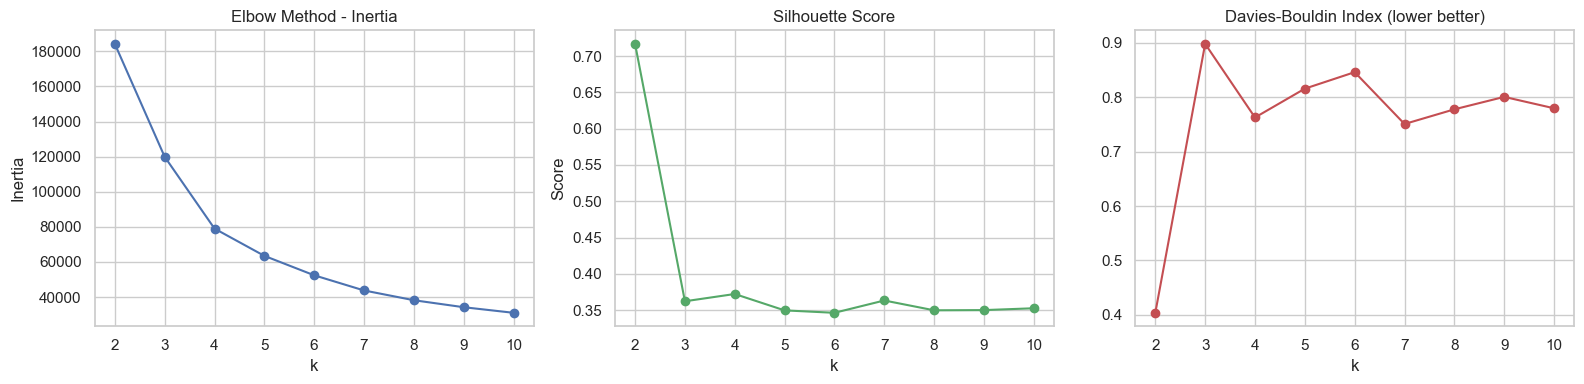

In [5]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))
axes[0].plot(ks, inertias, 'o-', color='#4C72B0')
axes[0].set_title('Elbow Method - Inertia'); axes[0].set_xlabel('k'); axes[0].set_ylabel('Inertia')
axes[1].plot(ks, sil_scores, 'o-', color='#55A868')
axes[1].set_title('Silhouette Score'); axes[1].set_xlabel('k'); axes[1].set_ylabel('Score')
axes[2].plot(ks, db_scores, 'o-', color='#C44E52')
axes[2].set_title('Davies-Bouldin Index (lower better)'); axes[2].set_xlabel('k')
plt.tight_layout()
plt.savefig(FIG_DIR / 'kmeans_k_selection.png', dpi=120, bbox_inches='tight')
plt.show()

### 4.1 Pilih k Optimal

Kombinasi visual elbow + silhouette + DB index biasanya menunjuk pada **k = 4** untuk dataset ini (silhouette tertinggi atau elbow paling nyata). Jika hasil eksekusi berbeda, sesuaikan variabel `K_OPT` di bawah.

In [6]:
K_OPT = KM_PARAMS["k_optimal"]
print("k optimal yang dipakai :", K_OPT)


k optimal yang dipakai : 4


## 5. Fit Model Final & Simpan

In [7]:
kmeans = KMeans(n_clusters=K_OPT, n_init=KM_PARAMS["n_init"],
                max_iter=KM_PARAMS["max_iter"], random_state=RANDOM_STATE)
rfm["Cluster"] = kmeans.fit_predict(X_scaled)

# Simpan model + scaler via joblib (lebih ringan & idiomatic untuk sklearn).
joblib.dump(
    {"scaler": scaler, "kmeans": kmeans, "feature_cols": feature_cols},
    MODELS_DIR / "kmeans_rfm.pkl",
)

metrics = {
    "k"             : int(K_OPT),
    "inertia"       : float(kmeans.inertia_),
    "silhouette"    : float(silhouette_score(X_scaled, rfm["Cluster"],
                                              sample_size=10000, random_state=RANDOM_STATE)),
    "davies_bouldin": float(davies_bouldin_score(X_scaled, rfm["Cluster"])),
    "n_samples"     : int(len(rfm)),
    "features"      : feature_cols,
}
with open(MODELS_DIR / "kmeans_metrics.json", "w") as f:
    json.dump(metrics, f, indent=2)
metrics


{'k': 4,
 'inertia': 79016.68191780744,
 'silhouette': 0.37238786056812095,
 'davies_bouldin': 0.76335405775903,
 'n_samples': 93357,
 'features': ['Recency_w', 'Frequency_log', 'Monetary_log']}

## 6. Profiling Cluster

In [8]:
profile = rfm.groupby('Cluster').agg(
    n_customers=('customer_unique_id', 'count'),
    Recency_mean=('Recency', 'mean'),
    Frequency_mean=('Frequency', 'mean'),
    Monetary_mean=('Monetary', 'mean'),
    Monetary_total=('Monetary', 'sum'),
).round(2)
profile['pct_customers'] = (profile['n_customers'] / profile['n_customers'].sum() * 100).round(2)
profile = profile.sort_values('Monetary_mean', ascending=False)
profile

,n_customers,Recency_mean,Frequency_mean,Monetary_mean,Monetary_total,pct_customers
Cluster,,,,,,
3,28156,173.24,1.00,315.31,8877992.97,30.16
2,2801,220.29,2.11,308.59,864357.21,3.00
1,27153,424.60,1.00,120.24,3264871.65,29.09
0,35247,147.22,1.00,68.52,2415239.94,37.76


### 6.1 Snake Plot — Profil Cluster pada Skala Standardisasi

Snake plot membantu melihat *posisi relatif* tiap cluster terhadap rata-rata populasi.

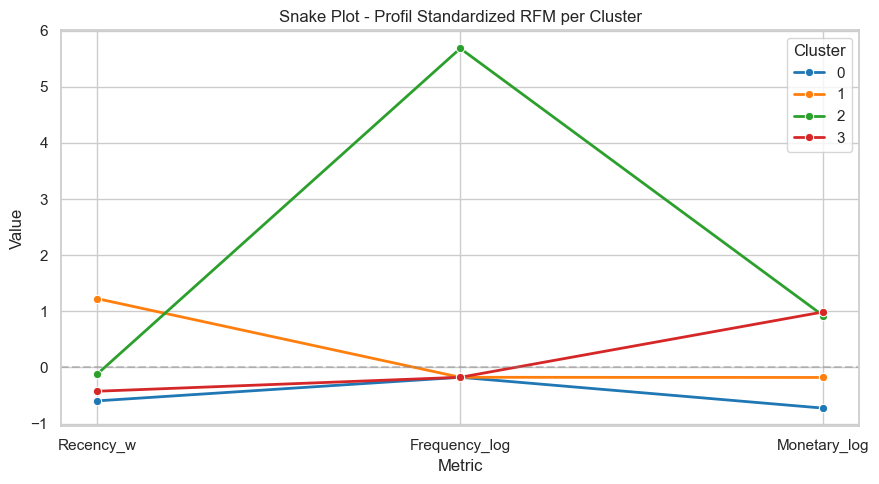

In [9]:
rfm_scaled = pd.DataFrame(X_scaled, columns=feature_cols)
rfm_scaled['Cluster'] = rfm['Cluster'].values
snake = rfm_scaled.groupby('Cluster').mean().reset_index().melt(
    id_vars='Cluster', var_name='Metric', value_name='Value')

fig, ax = plt.subplots(figsize=(9, 5))
sns.lineplot(data=snake, x='Metric', y='Value', hue='Cluster',
             marker='o', linewidth=2, ax=ax, palette='tab10')
ax.axhline(0, color='gray', linestyle='--', alpha=0.4)
ax.set_title('Snake Plot - Profil Standardized RFM per Cluster')
plt.tight_layout()
plt.savefig(FIG_DIR / 'cluster_snake_plot.png', dpi=120, bbox_inches='tight')
plt.show()

### 6.2 Distribusi Pelanggan per Cluster

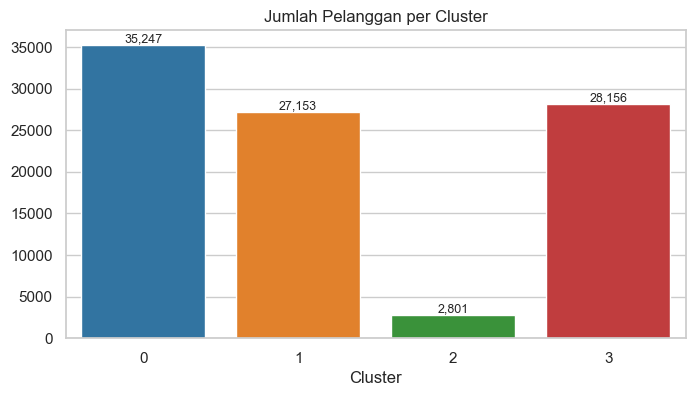

In [10]:
fig, ax = plt.subplots(figsize=(8, 4))
cnt = rfm['Cluster'].value_counts().sort_index()
sns.barplot(x=cnt.index, y=cnt.values, ax=ax, palette='tab10')
ax.set_title('Jumlah Pelanggan per Cluster')
for i, v in enumerate(cnt.values):
    ax.text(i, v, f'{v:,}', ha='center', va='bottom', fontsize=9)
plt.savefig(FIG_DIR / 'cluster_size.png', dpi=120, bbox_inches='tight')
plt.show()

### 6.3 Visualisasi 2D dengan PCA

PCA digunakan **hanya untuk visualisasi**, bukan untuk training.

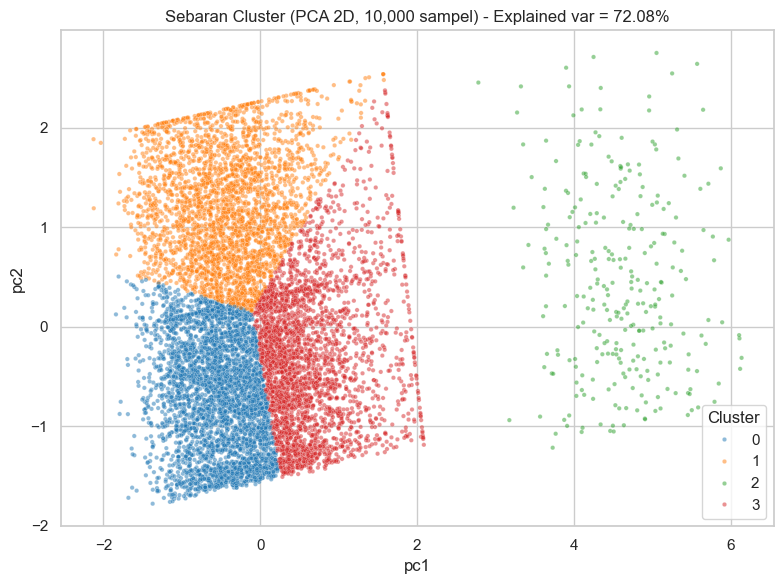

In [11]:
pca = PCA(n_components=2, random_state=RANDOM_STATE)
X_pca = pca.fit_transform(X_scaled)
rfm['pc1'], rfm['pc2'] = X_pca[:, 0], X_pca[:, 1]

fig, ax = plt.subplots(figsize=(8, 6))
sample = rfm.sample(min(10000, len(rfm)), random_state=RANDOM_STATE)
sns.scatterplot(data=sample, x='pc1', y='pc2', hue='Cluster',
                palette='tab10', alpha=0.5, s=10, ax=ax)
ax.set_title(f'Sebaran Cluster (PCA 2D, {len(sample):,} sampel) - Explained var '
             f'= {pca.explained_variance_ratio_.sum():.2%}')
plt.tight_layout()
plt.savefig(FIG_DIR / 'cluster_pca_scatter.png', dpi=120, bbox_inches='tight')
plt.show()

## 7. Penamaan Segmen & Rekomendasi Strategi

Penamaan dilakukan **berdasarkan profile** (rata-rata R/F/M). Mapping di bawah merupakan template; sesuaikan dengan hasil cluster Anda yang sebenarnya.

In [12]:
# Label segment data-driven berdasarkan posisi relatif tiap cluster.
# Tidak memakai threshold absolut yang membuat 'At Risk' tidak pernah tercapai.
_med_recency  = profile["Recency_mean"].median()
_med_monetary = profile["Monetary_mean"].median()
_med_freq     = profile["Frequency_mean"].median()

def label_segment(row):
    recent = row["Recency_mean"] <= _med_recency
    high_value = row["Monetary_mean"] >= _med_monetary
    high_freq = row["Frequency_mean"] >= _med_freq
    if recent and high_value and high_freq:
        return "Champions"
    if recent and high_freq:
        return "Loyal Customers"
    if recent:
        return "Potential Loyalists"
    if high_value:
        return "At Risk"          # lama tidak transaksi tapi nilainya besar
    return "Hibernating / Lost"

profile["Segment"] = profile.apply(label_segment, axis=1)
segment_map = profile["Segment"].to_dict()
rfm["Segment"] = rfm["Cluster"].map(segment_map)
profile


,n_customers,Recency_mean,Frequency_mean,Monetary_mean,Monetary_total,pct_customers,Segment
Cluster,,,,,,,
3,28156,173.24,1.00,315.31,8877992.97,30.16,Champions
2,2801,220.29,2.11,308.59,864357.21,3.00,At Risk
1,27153,424.60,1.00,120.24,3264871.65,29.09,Hibernating / Lost
0,35247,147.22,1.00,68.52,2415239.94,37.76,Loyal Customers


### 7.1 Rekomendasi Strategi Pemasaran per Segmen

| Segmen | Karakteristik | Rekomendasi Strategi |
|---|---|---|
| **Champions** | Recency rendah, Monetary tinggi | Program VIP, akses produk eksklusif, referral incentive. |
| **Loyal Customers** | Sering belanja, recency moderat | Loyalty program, cross-sell, voucher repeat order. |
| **Potential Loyalists** | Baru, transaksi medium | Onboarding email, rekomendasi personal, free shipping pertama berikutnya. |
| **At Risk** | Sudah lama tidak transaksi tapi pernah loyal | Reaktivasi: diskon win-back, survey kepuasan. |
| **Hibernating / Lost** | Sangat lama tidak aktif | Kampanye reaktivasi besar (banner discount, push notif), atau hentikan komunikasi marketing untuk efisiensi. |

## 8. Simpan Hasil Final

In [13]:
out_path = PROCESSED_DIR / 'rfm_segmented.csv'
cols_keep = ['customer_unique_id', 'Recency', 'Frequency', 'Monetary',
             'R_score', 'F_score', 'M_score', 'RFM_score',
             'Cluster', 'Segment']
rfm[cols_keep].to_csv(out_path, index=False)
print('Tersimpan ->', out_path)
rfm[cols_keep].head()

Tersimpan -> /Users/rafafawwaz/Documents/sem 6/PDM/Riset Data Mining - Rafa/data/processed/rfm_segmented.csv


,customer_unique_id,Recency,Frequency,Monetary,R_score,F_score,M_score,RFM_score,Cluster,Segment
0,0000366f3b9a7992bf8c76cfdf3221e2,112,1,141.90,4,1,4,414,3,Champions
1,0000b849f77a49e4a4ce2b2a4ca5be3f,115,1,27.19,4,1,1,411,0,Loyal Customers
2,0000f46a3911fa3c0805444483337064,537,1,86.22,1,1,2,112,1,Hibernating / Lost
3,0000f6ccb0745a6a4b88665a16c9f078,321,1,43.62,2,1,1,211,1,Hibernating / Lost
4,0004aac84e0df4da2b147fca70cf8255,288,1,196.89,2,1,4,214,3,Champions


## 9. Kesimpulan

1. Tabel RFM (~ 95k pelanggan) berhasil di-cluster menggunakan **K-Means** dengan k optimal berdasarkan elbow + silhouette + Davies–Bouldin.
2. Setiap cluster memiliki **profil R/F/M yang khas**, divisualisasikan via snake plot dan PCA scatter.
3. Segmen-segmen yang teridentifikasi memungkinkan tim pemasaran untuk **men-target kampanye** secara presisi (alih-alih *one-size-fits-all*) sehingga menjawab masalah penelitian.
4. Output utama disimpan di:
   - `models/kmeans_rfm.pkl`           → model + scaler
   - `models/kmeans_metrics.json`       → metrik kualitas cluster
   - `data/processed/rfm_segmented.csv` → tabel pelanggan + segmen
5. Pipeline ini terhubung ke **DVC** sehingga setiap perubahan dataset otomatis ter-version.

*End of pipeline.*